In [ ]:
# pip install matplotlib
# pip install scikit-learn
# pip install sentence_transformers
# pip install seaborn
# pip install langdetect
# pip install textstat
# pip install langid

In [107]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import re
import unicodedata
import codecs
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException
import textstat
import langid

In [2]:
# Make language detection deterministic
DetectorFactory.seed = 0

In [3]:
pd.set_option('display.max_colwidth', None)

# Util code

In [ ]:
def remove_newlines_and_encoded(text):
    if not isinstance(text, str):
        return ""
    # Replace encoded newlines, tabs, carriage returns
    text = re.sub(r'(\\r|\\n|\\t)+', '. ', text)
    # Replace actual newlines, tabs, carriage returns
    text = re.sub(r'[\r\n\t]+', '. ', text)
    # Remove unicode escape sequences like \uXXXX or \xXX
    text = re.sub(r'(\\u[0-9a-fA-F]{4}|\\x[0-9a-fA-F]{2})', '', text)
    # Collapse multiple spaces
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def remove_abbreviation_dots(text):
    if not isinstance(text, str):
        return ""
    # Remove dots between single uppercase letters (e.g., U.S.A. → USA)
    return re.sub(r'(?<=\b[A-Z])\.(?=[A-Z]\b)', '', text)

def protect_numeric_dots(text):
    # Replace dots between digits with a special token
    return re.sub(r'(?<=\d)\.(?=\d)', '<DOT>', text)

def restore_numeric_dots(text):
    # Restore the protected dots
    return text.replace('<DOT>', '.')

def is_english(text: str) -> bool:
    if not text or not text.strip():
        return False
    
    # Quick check for obvious non-English: too few ASCII letters
    if len(re.findall(r"[a-zA-Z]", text)) / max(len(text), 1) < 0.5:
        return False
    
    
    lang, _ = langid.classify(text)
    return lang == "en"

def filter_news_text(
    text: str,
    lang: str = "en",
    non_ascii_threshold: float = 0.3,
    min_length: int = 30,
    run_lang_detect: bool = True
) -> bool:
    """
    Filter out low-quality or irrelevant news text before processing.

    Args:
        text (str): The text to check.
        lang (str): Target language (default: "en").
        non_ascii_threshold (float): Max allowed ratio of non-ASCII chars.
        min_length (int): Minimum length after removing URLs/placeholders.
        run_lang_detect (bool): Whether to run language detection.

    Returns:
        bool: True if text passes all filters, False otherwise.
    """
    if not text or not text.strip():
        return False
    
    # 1. Non-ASCII character ratio
    non_ascii_ratio = sum(1 for ch in text if ord(ch) > 127) / len(text)
    if non_ascii_ratio > non_ascii_threshold:
        return False

    # 2. Remove media placeholders & URLs
    text_no_media = re.sub(r"\[.*?\]", "", text)
    text_no_urls = re.sub(r"http\S+", "", text_no_media)
    
    # 3. Check cleaned length
    if len(text_no_urls.strip()) < min_length:
        return False

    # 4. Optional language detection
    if run_lang_detect:
        detected_lang, _ = langid.classify(text_no_urls)
        if detected_lang != lang:
            return False

    return True

In [ ]:
def clean_text(text: str, ascii_only: bool = True) -> str:
    """
    Clean and normalize a text string for further processing.

    Steps include:
    - Lowercasing
    - Removing accents
    - Stripping URLs
    - Removing punctuation
    - Collapsing whitespace

    Args:
        text (str): The input string to clean.

    Returns:
        str: Cleaned and normalized text.
    """
    if not isinstance(text, str):
        return ""
    
    if re.search(r'\\u[0-9a-fA-F]{4}|\\x[0-9a-fA-F]{2}', text):
        try:
            text = codecs.decode(text, 'unicode_escape')
        except Exception:
            pass  # in case decode fails

    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # remove URLs
    text = re.sub(r"\s+", " ", text)  # normalize whitespace

    if ascii_only:
        text = text.lower()
        text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8")  # remove accents
        text = protect_numeric_dots(text)
        text = remove_abbreviation_dots(text)
        text = remove_newlines_and_encoded(text)
        # text = re.sub(r"[^\w\s]", "", text)  # remove punctuation
    else:
        replacements = {
            "‘": "'", "’": "'",     # single quotes
            "“": '"', "”": '"',     # double quotes
            "–": "-", "—": "-",     # hyphens
            "…": "...",             # ellipsis
            "š": "",
            "\u2060": "",
        }

        for orig, repl in replacements.items():
            text = text.replace(orig, repl)

    text = re.sub(r'(\.\.\.|…)\s*$', '', text)   
    return text

def split_sentences(text: str) -> list:
    """
    Splits mixed-language text into sentences using both Western and Asian punctuation.
    """
    # Define sentence-ending punctuation for various scripts
    sentence_delimiters = [
        # English/European (with space)
        r'(?<=[.!?])\s+',
        # Japanese/Chinese/Korean (no space required)
        r'(?<=[。！？])',
        # Arabic question mark
        r'(?<=[؟])',
        # Hindi danda
        r'(?<=[।])',
        # Full-width period, exclamation, question (used in CJK)
        r'(?<=[\u3002\uFF01\uFF1F])',
        # Bracket/quote-like separators in multiple languages
        r'[「」『』【】《》〈〉〔〕“”‘’"\'«»„“‹›\[\]\(\)\{\}]'
    ]
    
    # Compile the final pattern
    pattern = "|".join(sentence_delimiters)
    
    # Split and clean
    sentences = [s.strip() for s in re.split(pattern, text) if s.strip()]
    return sentences

def is_likely_english(text, min_words = 3, min_syllables = 3):
    """Heuristic: returns True if text has enough words and syllables to be English."""
    if not isinstance(text, str) or not text.strip():
        return False
    return textstat.syllable_count(text) >= min_syllables and len(text.split()) >= min_words

def keep_english_sentences(text: str) -> str:
    """Return only English sentences from the mixed-language input."""
    sentences = split_sentences(text)
    english_sentences = []

    for sent in sentences:
        aux = sent.strip()
        if is_english(aux):
            english_sentences.append(aux)
    
    return '. '.join(english_sentences)

def count_words(text: str) -> int:
    """
    Counts the number of words in a text.
    Words are considered as sequences separated by whitespace.
    """
    if not isinstance(text, str):
        return 0
    return len(text.strip().split())

In [108]:
text = 'Increased AI competition worsens surveillance, manipulation, and disinformation threatening privacy, autonomy, and democracy.	'

print("Flesch Reading Ease:", textstat.flesch_reading_ease(text))
print("Flesch-Kincaid Grade:", textstat.flesch_kincaid_grade(text))
print("Gunning Fog:", textstat.gunning_fog(text))
print("SMOG Index:", textstat.smog_index(text))
print("Coleman-Liau Index:", textstat.coleman_liau_index(text))
print("Automated Readability Index:", textstat.automated_readability_index(text))
print("Dale-Chall Score:", textstat.dale_chall_readability_score(text))

Flesch Reading Ease: -53.65230769230766
Flesch-Kincaid Grade: 23.97230769230769
Gunning Fog: 29.81538461538462
SMOG Index: 19.287186520377343
Coleman-Liau Index: 30.107692307692314
Automated Readability Index: 26.010769230769228
Dale-Chall Score: 17.64206923076923


# General check

In [128]:
# Load your processed or intermediate dataset
df = pd.read_json(Path("../data/02_intermediate/merged_and_deduplicated.jsonl"), lines = True)

# Show structure
df.info()
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72855 entries, 0 to 72854
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         72854 non-null  object 
 1   summary       71266 non-null  object 
 2   published_dt  72855 non-null  object 
 3   target        72855 non-null  object 
 4   source        72855 non-null  object 
 5   summary_len   71266 non-null  float64
dtypes: float64(1), object(5)
memory usage: 3.3+ MB


,title,summary,published_dt,target,source,summary_len
0,EU frozen out of Arctic opportunities by Russia sanctions \u2013 FT,"The use of the Northern Sea Route could substantially slash logistics costs, but geopolitical risks deter major players, FT wrote",2025-06-09 13:59:40,business,fcsapi,129.0
1,Coinbase Alum-Founded Turnkey Raises $30M Series B to Grow Engineering Team: Report,The funding round was led by Bain Capital Crypto and included contributions from Lightspped Faction and Galaxy Ventures.,2025-06-09 10:21:26,business,fcsapi,120.0
2,OpenLedger Commits $25M to Fund AI Blockchain Startups,The blockchain protocol raised $8 million in a seed round last year.,2025-06-09 09:31:08,business,fcsapi,68.0


In [129]:
# Check for duplicate titles
duplicate_titles = df[df.duplicated(subset='title', keep=False)]
print(f"Duplicate titles: {len(duplicate_titles)}")
display(duplicate_titles[['title', 'summary', 'source', 'target']].head(10))

# Check for duplicate title+summary pairs
duplicate_pairs = df[df.duplicated(subset=['title', 'summary'], keep=False)]
print(f"Duplicate title+summary pairs: {len(duplicate_pairs)}")
display(duplicate_pairs[['title', 'summary', 'source', 'target']].head(10))

Duplicate titles: 0


,title,summary,source,target


Duplicate title+summary pairs: 0


,title,summary,source,target


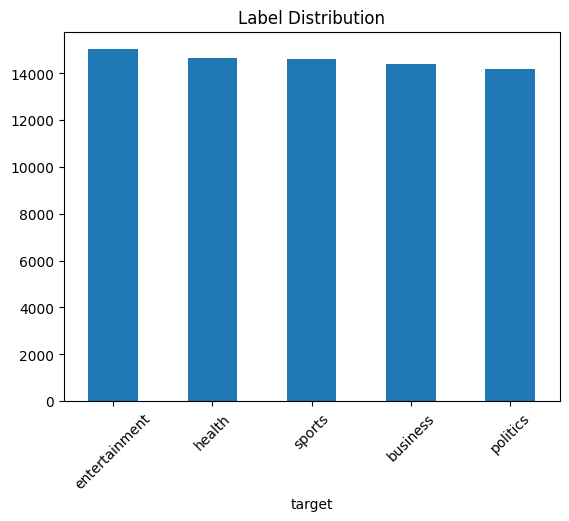

In [130]:
df['target'].value_counts().plot(kind='bar', title='Label Distribution')
plt.xticks(rotation = 45)
plt.show()

## Missing values

In [131]:
# Count missing or empty titles and summaries
print("Missing titles:", df['title'].isna().sum())
print("Missing summaries:", df['summary'].isna().sum())

# Fill NaN with empty string for further checks
df['title'] = df['title'].fillna("")
df['summary'] = df['summary'].fillna("")

# Count truly empty (after stripping whitespace)
empty_titles = df[df['title'].str.strip() == ""]
empty_summaries = df[df['summary'].str.strip() == ""]

print(f"Empty titles: {len(empty_titles)}")
print(f"Empty summaries: {len(empty_summaries)}")

# Show some examples
display(empty_titles[['summary', 'target', 'source']].head())
display(empty_summaries[['title', 'target', 'source']].head())

# Distribution by source/target
print("Empty titles by source:")
print(empty_titles['source'].value_counts())
print("Empty summaries by source:")
print(empty_summaries['source'].value_counts())

Missing titles: 1
Missing summaries: 1589
Empty titles: 1
Empty summaries: 2382


,summary,target,source
55773,Yahoo Sports senior NBA reporter Vincent Goodwill and The Athletic's James Edwards III discuss Chris Paul's announcement that he will retire after the 2025-26 NBA season and deliberate where he ranks among the league's greatest point guards of all-time. Hear …,sports,newsapi


,title,target,source
5199,Daylight Saving Time sheds light on lack of sleep\u2019s disproportionate impact in communities of color,health,fcsapi
5290,A global epidemic of cancer among people younger than 50 could be emerging,health,fcsapi
11916,"Brazil finance official flags debt concern, but urges time for gradual fiscal adjustment",business,newsapi
11925,E-commerce SME funding surge in north-west England – 365 Finance,business,newsapi
11927,Blackstone's gambling co Cirsa expects share listing in Spain on July 9,business,newsapi


Empty titles by source:
source
newsapi    1
Name: count, dtype: int64
Empty summaries by source:
source
newsapi      1818
worldnews     562
fcsapi          2
Name: count, dtype: int64


In [132]:
# Text length
df['title'] = df['title'].fillna("")
df['summary'] = df['summary'].fillna("")
print("Missing titles:", df['title'].isna().sum())
print("Missing summaries:", df['summary'].isna().sum())

Missing titles: 0
Missing summaries: 0


In [133]:
display(df['title'].str.extract(r"(\\u\d{4})").value_counts().head(10))

display(df['summary'].str.extract(r"(\\u\d{4})").value_counts().head(10))

0     
\u2019    972
\u2018    445
\u2014    375
\u2013     55
\u2026      2
Name: count, dtype: int64

0     
\u2019    1904
\u2014     966
\u2013     113
\u2018     110
\u0161       1
\u2026       1
\u2060       1
Name: count, dtype: int64

## Cleaning and readibility

In [134]:
# Cleaned text columns
df["cleaned_title"] = df["title"].apply(clean_text)
df["cleaned_summary"] = df["summary"].apply(clean_text)
df["cleaned_title"] = df["cleaned_title"].apply(keep_english_sentences)
df["cleaned_summary"] = df["cleaned_summary"].apply(keep_english_sentences)
# df['cleaned_title'] = df['cleaned_title'].str.replace(r'\.\.\.$', '', regex=True).str.strip()
# df['cleaned_summary'] = df['cleaned_summary'].str.replace(r'\.\.\.$', '', regex=True).str.strip()

In [135]:
# Readability scores
df['summary_readability'] = df['summary'].apply(lambda x: textstat.flesch_reading_ease(x) if isinstance(x, str) else None)
df['cleaned_summary_readability'] = df['cleaned_summary'].apply(lambda x: textstat.flesch_reading_ease(x) if isinstance(x, str) else None)
df['title_readability'] = df['title'].apply(lambda x: textstat.flesch_reading_ease(x) if isinstance(x, str) else None)
df['cleaned_title_readability'] = df['cleaned_title'].apply(lambda x: textstat.flesch_reading_ease(x) if isinstance(x, str) else None)

In [136]:
df[['summary_readability', 'cleaned_summary_readability', 'title_readability', 'cleaned_title_readability']].describe()

,summary_readability,cleaned_summary_readability,title_readability,cleaned_title_readability
count,72855.000000,72855.000000,72855.000000,72855.000000
mean,45.370725,48.865233,53.012791,52.701019
std,25.907512,23.628672,26.475575,28.855912
min,-501.210000,-78.210000,-217.180000,-301.780000
25%,31.115000,34.676667,37.455385,35.945000
50%,47.300000,50.470769,55.215294,56.700000
75%,61.333333,64.469318,71.065000,72.615455
max,121.220000,121.220000,121.220000,121.220000


In [141]:
df.nsmallest(5, 'summary_readability')[['summary', 'summary_readability', 'cleaned_summary', 'cleaned_summary_readability', 'cleaned_title']]

,summary,summary_readability,cleaned_summary,cleaned_summary_readability,cleaned_title
27005,[株式会社THINKR]\n[画像1: https://prcdn.freetls.fastly.net/release_image/106737/388/106737-388-7ddc9d830eb371c3484bd617f2b0da45-2048x960.jpg?width=536&quality=85%2C75&format=jpeg&auto=webp&fit=bounds...,-501.21,thinkr. 1:,120.205,
23269,[JeSU]\n[画像1: https://prcdn.freetls.fastly.net/release_image/39144/185/39144-185-1856e0f1b40cb6ecdf29cdf3d19f6563-1536x984.png?width=536&quality=85%2C75&format=jpeg&auto=webp&fit=bounds&a...,-473.01,1:,121.220,
47786,[ドクターリセラ株式会社]\n[画像1: https://prcdn.freetls.fastly.net/release_image/37333/252/37333-252-3390079e2865db1d3c24a88fa94dc3ec-900x600.png?width=536&quality=85%2C75&format=jpeg&auto=webp&fit=bounds&am...,-473.01,1:,121.220,
23998,[日本コロムビア株式会社]\n[画像1: https://prcdn.freetls.fastly.net/release_image/19470/4393/19470-4393-6b85eb9cbd52528f9e0dd8e47cc8e2a6-1080x1080.jpg?width=536&quality=85%2C75&format=jpeg&auto=webp&fit=bound...,-444.81,1:,121.220,unisisters!!
30614,[プルミエール・ヴィジョン・ジャパン株式会社]\n[画像1: https://prcdn.freetls.fastly.net/release_image/163814/1/163814-1-de6ebb788daae1a8baa39620262417da-1952x2700.jpg?width=536&quality=85%2C75&format=jpeg&auto=webp&fit=bounds&am...,-444.81,1:,121.220,


In [139]:
df.nsmallest(5, 'summary_readability')['summary']

27005               [株式会社THINKR]\n[画像1: https://prcdn.freetls.fastly.net/release_image/106737/388/106737-388-7ddc9d830eb371c3484bd617f2b0da45-2048x960.jpg?width=536&quality=85%2C75&format=jpeg&auto=webp&fit=bounds...
23269                     [JeSU]\n[画像1: https://prcdn.freetls.fastly.net/release_image/39144/185/39144-185-1856e0f1b40cb6ecdf29cdf3d19f6563-1536x984.png?width=536&quality=85%2C75&format=jpeg&auto=webp&fit=bounds&a...
47786              [ドクターリセラ株式会社]\n[画像1: https://prcdn.freetls.fastly.net/release_image/37333/252/37333-252-3390079e2865db1d3c24a88fa94dc3ec-900x600.png?width=536&quality=85%2C75&format=jpeg&auto=webp&fit=bounds&am...
23998              [日本コロムビア株式会社]\n[画像1: https://prcdn.freetls.fastly.net/release_image/19470/4393/19470-4393-6b85eb9cbd52528f9e0dd8e47cc8e2a6-1080x1080.jpg?width=536&quality=85%2C75&format=jpeg&auto=webp&fit=bound...
30614    [プルミエール・ヴィジョン・ジャパン株式会社]\n[画像1: https://prcdn.freetls.fastly.net/release_image/163814/1/163814-1-de6ebb788daae1a8baa39620262

In [138]:
df.nsmallest(5, 'cleaned_summary_readability')[['summary', 'summary_readability', 'cleaned_summary', 'cleaned_summary_readability']]

,summary,summary_readability,cleaned_summary,cleaned_summary_readability
66862,"Само месец и половина след своя старт онлайн платформата на Електрохолд Продажби – ENERGOTO.BG – вече осигурява електроенергия за над 1600 търговски и бизнес обекта, които избраха новия план с атрактивни отстъпки и изцяло онлайн обслужване.\nСъздадена с фокус върху малкия и средния бизнес, платформата ENERGOTO",93.889242,"energoto.bg 1600 , .. , energoto",-78.210000
24125,"Read changelog.txt for information on updated content! Genre: Simulation, StrategyDeveloper: Stardock EntertainmentPublisher: Stardock Entertainment Release Name: Galactic.Civilizations.IV.Supernova.Tales.of.the.Arnor.Update.v3.0-RUNESize: 107.3 MBLinks: STEA…",-66.421667,"read changelog.txt for information on updated content!. genre: simulation, strategydeveloper: stardock entertainmentpublisher: stardock entertainment release name: galactic.civilizations.iv.supernova.tales.of.the.arnor.update.v3<DOT>0-runesize: 107<DOT>3 mblinks: stea",-74.881667
49070,"Increased AI competition worsens surveillance, manipulation, and disinformation—threatening privacy, autonomy, and democracy.",-73.245000,"increased ai competition worsens surveillance, manipulation, and disinformationthreatening privacy, autonomy, and democracy.",-73.245000
34895,Immuthera’s Scientific Advisory Board: World-Leading Expertise Driving Next-Generation Diabetes and Immunotherapy Solutions Distinguished experts...,-55.132143,immutheras scientific advisory board: world-leading expertise driving next-generation diabetes and immunotherapy solutions distinguished experts,-55.132143
43132,"Organizations across finance, healthcare, manufacturing, and retail leverage monitoring for enhanced IT agility, compliance, and security, spurring demand for innovative, predictive monitoring solutions Organizations across finance, healthcare, manufacturing,…",-54.235000,"organizations across finance, healthcare, manufacturing, and retail leverage monitoring for enhanced it agility, compliance, and security, spurring demand for innovative, predictive monitoring solutions organizations across finance, healthcare, manufacturing,",-54.235000


## Subtotals

In [25]:
# Top sources or categories
display(df['source'].value_counts().head(10))
display(df.target.value_counts())

source
newsapi      53149
fcsapi       11806
worldnews     7900
Name: count, dtype: int64

target
entertainment    15034
health           14653
sports           14619
business         14384
politics         14165
Name: count, dtype: int64

In [26]:
df.groupby(['target', 'source']).agg({'published_dt': ['min', 'max', 'count']}).reset_index().sort_values(by = ['target', 'source'])

target     source          published_dt                        \
                                               min                   max   
0        business     fcsapi   2022-03-31 18:03:06   2025-06-09 13:59:40   
1        business    newsapi  2025-07-01T00:00:00Z  2025-07-16T23:58:58Z   
2        business  worldnews   2025-07-29 07:15:02   2025-08-06 04:45:00   
3   entertainment     fcsapi   2022-01-03 22:27:41   2025-06-09 09:26:19   
4   entertainment    newsapi  2025-07-01T00:00:00Z  2025-07-24T23:59:12Z   
5   entertainment  worldnews   2025-08-01 05:25:38   2025-08-06 05:01:01   
6          health     fcsapi   2022-01-01 00:51:05   2025-06-09 13:00:03   
7          health    newsapi  2025-07-01T00:00:00Z  2025-07-28T23:47:07Z   
8          health  worldnews   2025-07-19 23:55:10   2025-08-06 03:53:25   
9        politics     fcsapi   2022-06-11 19:29:51   2025-06-09 14:02:29   
10       politics    newsapi  2025-07-01T00:05:21Z  2025-07-16T23:37:41Z   
11       politics  worldnews   2025-08-05 18:04:54   2025-08-06 04:58:27   
12         sports     fcsapi   2022-04-25 03:16:19   2025-06-08 03:00:18   
13         sports    newsapi  2025-07-01T00:00:01Z  2025-07-24T23:57:23Z   
14         sports  worldnews   2025-08-03 14:00:00   2025-08-06 05:00:00   

           
    count  
0    2970  
1    9494  
2    1920  
3     895  
4   12188  
5    1951  
6    1914  
7   12541  
8     198  
9    5890  
10   6354  
11   1921  
12    137  
13  12572  
14   1910

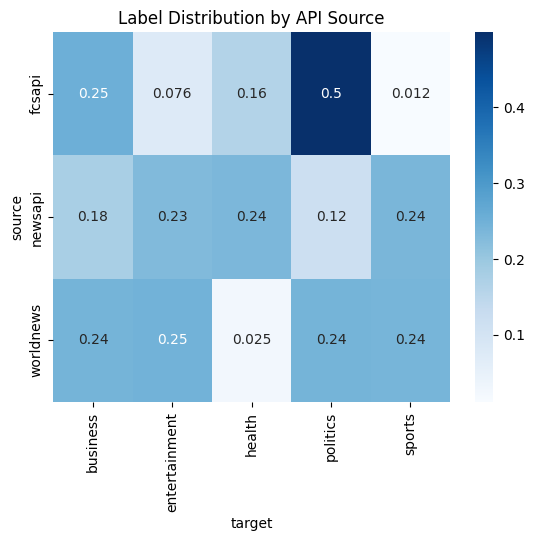

In [27]:
sns.heatmap(pd.crosstab(df['source'], df['target'], normalize ='index'), annot = True, cmap = "Blues")
plt.title("Label Distribution by API Source")
plt.show()

## Length analysis

          title_len   summary_len
count  72855.000000  72855.000000
mean      73.453998    181.351781
std       25.379107    106.403206
min        0.000000      0.000000
25%       58.000000    119.000000
50%       71.000000    165.000000
75%       86.000000    260.000000
max     1711.000000   1024.000000


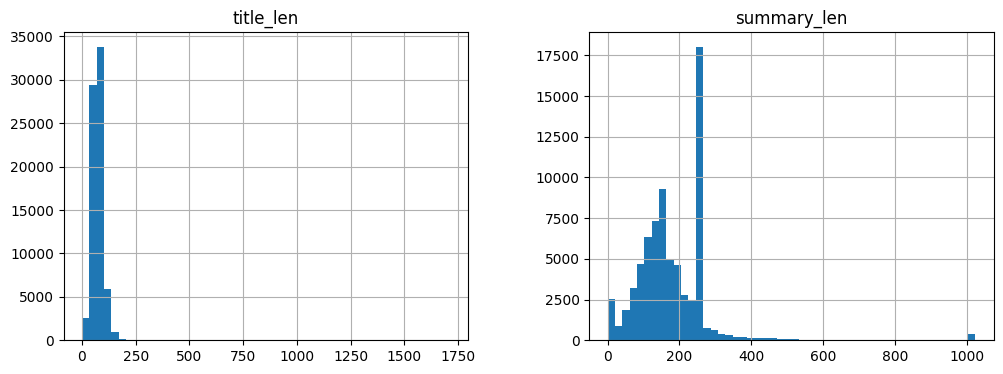

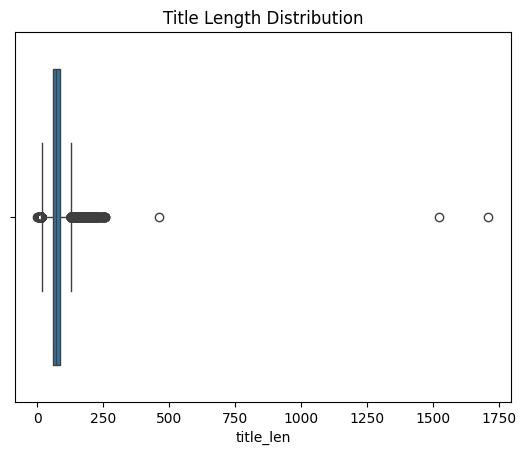

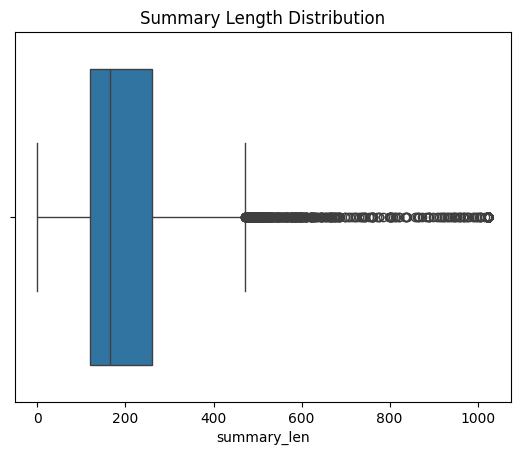

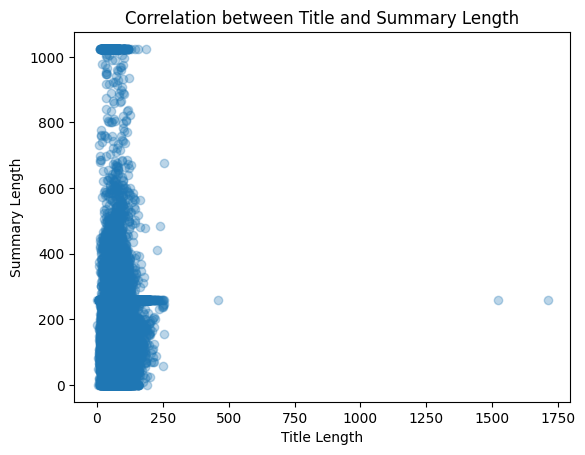

Correlation coefficient: 0.007323501808150318


In [64]:
# Calculate lengths
df['title_len'] = df['title'].str.len()
df['summary_len'] = df['summary'].str.len()

# Show descriptive statistics
print(df[['title_len', 'summary_len']].describe())

# Plot histograms
df[['title_len', 'summary_len']].hist(bins=50, figsize=(12, 4))
plt.show()

# Boxplots for outlier detection
sns.boxplot(x=df['title_len'])
plt.title("Title Length Distribution")
plt.show()

sns.boxplot(x=df['summary_len'])
plt.title("Summary Length Distribution")
plt.show()

plt.scatter(df['title_len'], df['summary_len'], alpha=0.3)
plt.xlabel('Title Length')
plt.ylabel('Summary Length')
plt.title('Correlation between Title and Summary Length')
plt.show()

print("Correlation coefficient:", df['title_len'].corr(df['summary_len']))

In [37]:
display(df['title_len'].mode())
display(df['summary_len'].mode())

0    70
Name: title_len, dtype: int64

0    260
Name: summary_len, dtype: int64

In [38]:
most_frequent = df[df['title_len'] == 70].copy()
most_frequent[['title', 'summary', 'source']].sample(5, random_state=42)

,title,summary,source
50757,Bitcoin retail interest ‘almost nowhere to be found’ as BTC taps highs,Bitcoin’s surge to all-time highs has barely moved the needle in Google search interest compared to the spike seen after Donald Trump won the US presidential election in November.,newsapi
36748,S&P 500 Gains & Losses Today: FICO Shares Plummet; Moderna Stock Rises,"The S&P 500 fell 0.1% on Tuesday, July 8, 2025, after President Trump extended the deadline for ""reciprocal"" tariffs and discussed a 50% levy on imported...",newsapi
60605,On Running Shoe Sale: Save Up To 36% On The Popular Sneakers Right Now,"During this On Running shoe sale, take up to 36% off walking and training shoes. Shop editor-approved pairs as well as top-rated options from the brand.",newsapi
25503,Linda Yaccarino to step down as CEO of Elon Musk's social media site X,Yaccarino led X through a tumultuous period as the social network tried to rebuild its relationship with brands concerned that their ads could show up next...,newsapi
24815,The Entire Run of ‘Squid Game’ Is Currently Dominating Netflix Ratings,"The just-released third season tops the streamer's charts, with seasons two and one right behind it.",newsapi


In [39]:
most_frequent = df[df['summary_len'] == 260].copy()
most_frequent[['title', 'summary', 'source']].sample(5, random_state=42)

,title,summary,source
47805,"Rep. Mark Green resigns from Congress, leaving Speaker Johnson with an even narrower Republican majority in the House","Rep. Mark Green, R-Tenn., announced his official resignation from Congress on Friday, a move that was expected but one that could, at least for now, shrink Republicans' already narrow majority in the House.\n""To my constituents across Tennessee's 7th District—…",newsapi
46745,Donald Trump’s Autocratic One-Man Government Regime: Doomed to Failure? But Not Before a Lot of Chaos and Destruction. Prof. Rodrigue Tremblay,"Democracy is presently threatened in some Western countries, notably in the United States.\nThe post Donald Trump’s Autocratic One-Man Government Regime: Doomed to Failure? But Not Before a Lot of Chaos and Destruction. Prof. Rodrigue Tremblay appeared first o…",newsapi
61780,DWU's Landon Ruesink selected as GPAC Duer Award nominee,"Jul. 18—SIOUX CITY, Iowa. — Dakota Wesleyan University football and baseball player Landon Ruesink has been selected as the Great Plains Athletic Conference's male nominee for the A.O. Duer Award. The national award has been presented since 1967 to a male and…",newsapi
27481,"19 Free AI Tools to Boost Creativity, Productivity, and Learning","What if you could supercharge your creativity, productivity, and learning—all without spending a dime? Artificial intelligence is no longer a futuristic concept; it’s a powerful tool that’s reshaping how we work, create, and solve problems. From crafting prof…",newsapi
34885,"Top American cardiologist shares 5 easy steps to lose 13 kg weight naturally, without any injection shot","A top American cardiologist, Dr. Sanjay Bhojraj, has shared a natural, drug-free method to lose up to 13.6 kg (30 pounds) without relying on injections like Ozempic. In a recent post, he outlined five evidence-backed lifestyle changes that help stimulate the …",newsapi


In [40]:
# Newsapi summaries are getting truncated by 260 characters
df[df['source'] == 'newsapi'].summary_len.max()

np.int64(260)

## Word count analysis

,title_words_count,summary_words_count
count,72855.000000,72855.000000
mean,11.782898,29.082808
std,4.179778,16.559417
min,0.000000,0.000000
25%,9.000000,19.000000
50%,11.000000,27.000000
75%,14.000000,39.000000
max,249.000000,197.000000


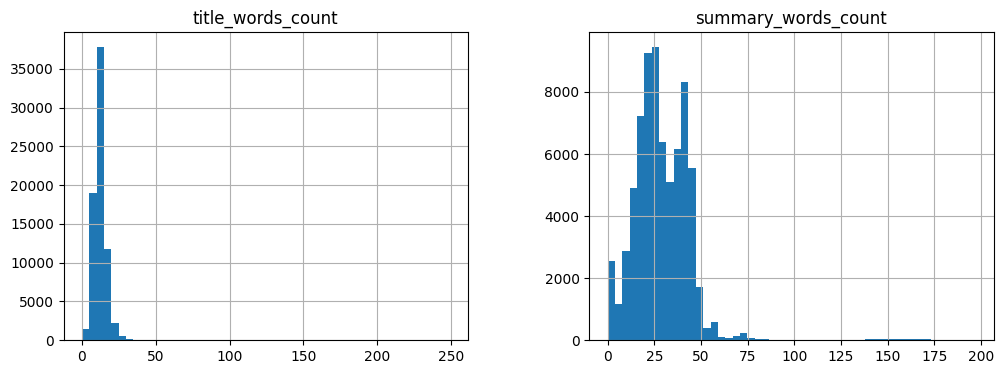

Titles with >50 words:


,title,summary,target
32427,"i was going to use the word ""fulsomely"" in this comic (""fulsomely considered"") but TURNS OUT the word had a negative connotation in the 1700s (going from ""full or abundant"" to ""excessive, offensive, and sickening"") to such an extent that the word was sometimes spelled ""foulsome"" and now it's a Risky Word to deploy because it's got both positive and negative meanings depending on who reads it. Sorry ""FULSOME"" but you are TOO MESSED UP to reasonably deploy!!","<table><tr><td><tr><td>archive - contact - sexy exciting merchandise - search - about</td></tr></td></tr></table><table><tr><td>← previous</td><td>July 23rd, 2025</td><td>next</td></tr><tr><td>July 23rd, 2025: HOPEFULLY THE MOVIE WAS GOOD!!– Ryan\r\n</td></tr><…",entertainment
50354,"Day 33 – Q. 2. A massive fire at the official residence of a sitting High Court judge uncovers bundles of charred currency notes amounting to several crores. Preliminary investigations suggest a serious case of financial misconduct, triggering nationwide outrage. A Supreme Court-appointed panel recommends initiating impeachment proceedings, putting the spotlight squarely on the integrity of the higher judiciary. This incident has sparked a fierce debate. While the legal community defends the sanctity and independence of the judiciary as essential to democracy, civil society, media, and common citizens demand immediate action and structural reforms to prevent such breaches of public trust. Many view this as a symptom of a deeper systemic issue, not merely an isolated moral failure. The Ministry of Law and Justice is now under pressure to institutionalize a credible framework that ensures accountability while preserving the independence of judges. As a senior bureaucrat, your role involves reconciling competing concerns: respecting judicial autonomy as guaranteed under the Constitution while reinforcing mechanisms of integrity, transparency, and public confidence. Questions What ethical values and constitutional principles are at stake in this situation? How can the judiciary be held accountable without undermining its independence? As a senior bureaucrat in the Ministry of Law and Justice, what should be your course of action to address this issue institutionally and ethically? (250 words, 20 marks)","Q. 2. A massive fire at the official residence of a sitting High Court judge uncovers bundles of charred currency notes amounting to several crores. Preliminary investigations suggest a serious case of financial misconduct, triggering nationwide outrage. A Su…",politics
38496,"Day 34 – Q. 1.Dr. Priya Sharma, a senior scientist at the Indian Council of Medical Research (ICMR), has been leading a critical research project on developing an affordable COVID-19 vaccine for rural populations. After 18 months of dedicated work, her team is on the verge of a major breakthrough. However, she discovers that her immediate supervisor, Dr. Rajan Kumar, has been secretly sharing confidential research data with a multinational pharmaceutical company in exchange for substantial personal financial gains. When Dr. Sharma confronts Dr. Kumar, he threatens to have her removed from the project and warns that exposing him would jeopardize the entire research initiative, potentially delaying the vaccine by years. He argues that the partnership with the multinational company would actually accelerate the vaccine’s development and global distribution, ultimately serving the greater good. Dr. Kumar also reminds her that he has significant influence over her career progression and research funding. Dr. Sharma is torn between her professional integrity and the potential consequences of whistleblowing. She knows that exposing the misconduct might lead to project delays, affecting millions of vulnerable people awaiting the vaccine. Simultaneously, she is aware that remaining silent would compromise scientific ethics and reward corrupt practices within the research establishment. Questio

Summaries with >100 words:


,title,summary,target,source
68756,"Yuzvendra Chahal breaks silence on his divorce with Dhanashree Verma, says he was 'faking' marriage, had suicidal thoughts","Indian cricketer Yuzvendra Chahal has made a shocking revelation about his relationship with ex-wife Dhanashree Verma.Speaking on a podcast, Chahal revealed that the marriage had been on shaky ground for a while.“Kaafi time se chal raha tha,” Chahal said, admitting they had been struggling for some time.He added that they chose to stay silent until a final decision was made.“We decided that we don’t want to show the people jab tak nahi ho jaata kyunki kya pata naa bhi hota. Humara yeh tha ki jab tak hum ek point pe jaa ke pahunchenge nahi, we are not going to say anything.”Despite their issues, the couple continued to post happy photos and videos online.",entertainment,worldnews
67292,Pamela Anderson Responds To Meghan Markle 'Rip-Off' Drama With 1 Perfect Line,"Meghan Markle and Pamela AndersonPamela Anderson has no time for catty comparisons to Meghan Markle. \n\nThe former Baywatch star appeared on Watch What Happens Live on Sunday, where host Andy Cohen asked if she found the Duchess of Sussex’s cooking show similar to her own. \n\n“On a scale from one to 10, how much of a rip-off did you feel like With Love, Meghan was of your show, Pamela’s Cooking with Love?” the host questioned, pointing out that there “were articles saying that these two shows were very similar”. \n\n“One,” Pamela said while shaking her head. “I didn’t [find them similar].”\n\nAndy continued: “One? On a scale from one to 10, a one. You did not see any similarities?” \n\n“I didn’t really look,” the Naked Gun actor explained before expertly shutting down any drama with one perfect line. “I didn’t invent cooking shows. So I mean – she’s just doing her thing.”\n\n\n\nPamela’s show was released in February 2025 on Amazon Prime, while Meghan’s show premiered on Netflix in March, after a two-month delay due to t",entertainment,worldnews
67341,Lindsay Lohan Left Hollywood To Protect Her Family From Paparazzi & Scary Fame Moments | N18G,"Lindsay Lohan says she still struggles with PTSD from being chased by paparazzi when she was younger. Now living in Dubai, she enjoys a quiet life with her family and protects her son’s privacy. She hopes no one has to go through what she did. Watch this video to know more. bollywood news | entertainment news live | latest bollywood news | bollywood | news18 | n18oc_moviesLiked the video? Please press the thumbs up icon and leave a comment. Subscribe to Showsha YouTube channel and never miss a video: https://www.youtube.com/c/SHOWSHAIndiaFollow Showsha on Instagram: https://www.instagram.com/showsha_/Follow Showsha on Facebook: https://www.facebook.com/showshaFollow Showsha on X: https://x.com/news18showshaFollow Showsha on Snapchat: https://snapchat.com/t/6YeotZeyMore entertainment and lifestyle news and updates on:https://www.news18.com/entertainment",entertainment,worldnews


Summaries with <5 words:


,title,summary
65693,HP electricity board records Rs 315 cr profit in FY25 after years of losses,
31257,"Scarlett Johansson Found A Fancy Way To Help Her Jurassic World Rebirth Co-Stars Relax Amid Filming, And I’m Feeling FOMO",This sounds so cool.
18355,Why NuScale Power Stock Soared 120.6% Higher in the First Half of 2025,
68574,Chaos & Arguments On Day 1 Of No Helmet No Fuel Rule In Bhopal,
67651,Stoic Siraj levels series for India with magic spell,
19821,"Gold price today, Tuesday, July 15, 2025: Gold opens flat ahead of inflation report",
36674,STUDY: Exercise DOESN'T Improve Mental Health After All? 'Placebo Effect'...,
17440,M&A trends in today’s packaging market,
48478,Anti-woke activist applauds his ‘friends’ at the New York Times for Zohran Mamdani college application ‘scoop’,
69077,Opposition's demand for discussion on votebandi non-negotiable: Congress,


In [61]:
# Word count for titles and summaries
df['title_words_count'] = df['title'].apply(lambda x: count_words(x))
df['summary_words_count'] = df['summary'].apply(lambda x: count_words(x))
display(df[['title_words_count', 'summary_words_count']].describe())

# Plot histograms
df[['title_words_count', 'summary_words_count']].hist(bins=50, figsize=(12, 4))
plt.show()

# Inspect outliers
print("Titles with >50 words:")
display(df[df['title_words_count'] > 50][['title', 'summary', 'target']].sample(3))

print("Summaries with >100 words:")
display(df[df['summary_words_count'] > 100][['title', 'summary', 'target', 'source']].sample(3))

print("Summaries with <5 words:")
display(df[df['summary_words_count'] < 5][['title', 'summary']].sample(10))

In [24]:
df[(df['summary_words_count'] < 5) & (df['summary_words_count'] > 0)][['title', 'summary']].sample(10)

,title,summary
23998,『ナンバーワン戦隊ゴジュウジャー』挿入歌「UniSisters」配信開始！！,[日本コロムビア株式会社]\n[画像1: https://prcdn.freetls.fastly.net/release_image/19470/4393/19470-4393-6b85eb9cbd52528f9e0dd8e47cc8e2a6-1080x1080.jpg?width=536&quality=85%2C75&format=jpeg&auto=webp&fit=bound...
22623,How Sutton Foster Reportedly Feels About Allegedly Facing Criticism From Boyfriend Hugh Jackman’s Ex-Wife,Here's the latest.
34860,Scientists issue warning after detecting concerning surge in infection in domestic cats: 'Should be closely monitored',"""Domestic cats are susceptible."""
36909,Are You Dealing With Hair Loss? 7 Nutrients To Add To Your Daily Routine For Growth,"Grow, baby, grow!"
54807,Why isn't Bronny James playing? Lakers guard surprisingly absent from Summer League,This was unexpected.
23708,"シリーズ累計120万部突破！鳴見なる原作の日常""崩壊""系ラブコメ「渡くんの××が崩壊寸前」Blu-ray BOX 12/24(水)より発売決定！",[株式会社ハピネット]\n[画像: https://prcdn.freetls.fastly.net/release_image/31422/2244/31422-2244-072c20333153e08046c85b4bc8a09d03-1920x2700.png?width=536&quality=85%2C75&format=jpeg&auto=webp&fit=bounds...
27509,Can't Paint Your Own Nails? This Shockingly Easy Tutorial Is Made For You,And it looks salon-grade.
58523,"New owners Lore, A-Rod detail plans for Wolves",Read more on ESPN
70238,REPORT: FBI Proves Trump’s DEI Purge Is Effective,'Merit and job performance'
21784,"'You Could Hear A Pin Drop': Ted Danson Recalls Cheers' Live Audience Not Laughing At The Jokes, And The Surprisingly Simple Reason Behind It",Talk about a twist!


# Empty titles/summaries

## Empty news

In [94]:
#Check empty news
df[((df['title_len'] == 0) & (df['summary_len'] == 0))]

,title,summary,published_dt,target,source,title_len,summary_len,title_words_count,summary_words_count


## Empty title

In [95]:
empty_titles = df[df['title_len'] == 0]
print(f"Empty titles: {len(empty_titles)}")
empty_titles[['summary', 'target', 'source']]

Empty titles: 1


,summary,target,source
49088,Yahoo Sports senior NBA reporter Vincent Goodwill and The Athletic's James Edwards III discuss Chris Paul's announcement that he will retire after the 2025-26 NBA season and deliberate where he ranks among the league's greatest point guards of all-time. Hear …,sports,newsapi


## Empty body

In [96]:
empty_summary_df = df[df['summary'].str.strip() == ""]
print(f"Number of rows with empty summary: {len(empty_summary_df)}")

Number of rows with empty summary: 1730


In [97]:
empty_summary_df[['title', 'target']].sample(5, random_state=42)

,title,target
19937,"Elon Musk Says There's No Tesla-xAI Merger Coming, But He's Open to an Investment",business
42465,Wildfires prompt evacuations in western Washington,politics
23272,‘Telecom Is the New Tequila’: Behind the Celebrity Wireless Boom,entertainment
54094,Save up to 40% on Hilton's newest all-inclusive resort in the Dominican Republic,business
42890,Texas cloud seeding operation triggers conspiratorial outrage after deadly floods,politics


In [98]:
empty_summary_df['target'].value_counts()

target
politics         828
business         721
health           111
entertainment     44
sports            26
Name: count, dtype: int64

In [99]:
empty_summary_df['source'].value_counts()

source
newsapi      1621
worldnews     107
fcsapi          2
Name: count, dtype: int64

In [100]:
empty_summary_df['title_len'].describe()

count    1730.000000
mean       73.054335
std        22.106280
min        10.000000
25%        59.000000
50%        70.000000
75%        84.000000
max       191.000000
Name: title_len, dtype: float64

# Outliers

## Title

count    72855.000000
mean        73.453998
std         25.379107
min          0.000000
1%          22.000000
5%          38.000000
50%         71.000000
95%        114.000000
99%        146.000000
max       1711.000000
Name: title_len, dtype: float64


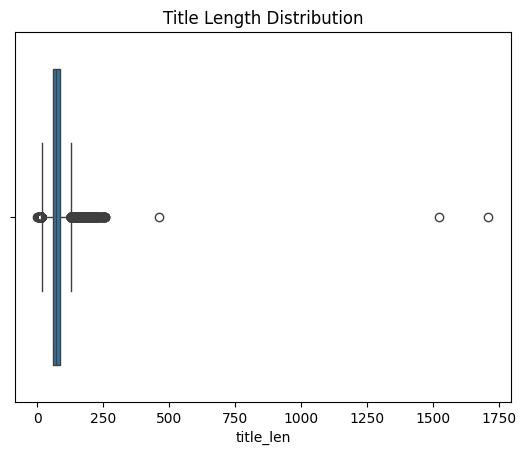

In [43]:
# Describe distribution
print(df['title_len'].describe(percentiles=[0.01, 0.05, 0.95, 0.99]))

# Possible outliers
short_titles = df[df['title_len'] < df['title_len'].quantile(0.01)]
long_titles = df[df['title_len'] > df['title_len'].quantile(0.99)]

# Visual boxplot
sns.boxplot(x=df['title_len'])
plt.title("Title Length Distribution")
plt.show()

In [113]:
short_titles[['title', 'summary', 'target']].sample(10)

,title,summary,target
21558,CelebNews,"CelebNews is a modern, mobile-optimized WordPress theme crafted for musicians, bands, singers, celebrity blogs, entertainment magazines, lifestyle news portals, and multimedia websites. With flexible layouts, responsive design, and bold styling, it’s ideal fo…",entertainment
37275,Wink Murder,"How “humour” opens the door to far right politics. By George Monbiot, published in the Guardian 10th July 2025 Imagine the furore if a Guardian columnist suggested bombing, say, the Conservative party conference and the Tory stronghold of Arundel in Sussex. I…",health
23292,The Ghost of Miranda,One subject that drew a lot of attention from Birch Bayh's Senate Subcommittee was Miranda. Blockbuster hearings were held in 1966 that included testimony by Arlen Specter (then a young prosecutor in Philadelphia fresh off serving on the Warren Commission) an…,entertainment
52633,Grass Court Power Shift,Janik Sinner renews his rivalry with a win over Alcaraz.,sports
29129,The Late Late Show,"Huh. In a decision that shocked the entertainment industry and comedy world, CBS said on Thursday that it was canceling the most-watched show in late night, “The Late Show With Stephen Colbert,” and retiring a franchise that has existed for more than three de…",entertainment
40798,Corbyn’s revenge,"Corbynism should have died a little past 3am on 13 December, 2019. Jeremy Corbyn delivered the eulogy himself at his general election count, declaring he would not lead the Labour Party into any future campaigns. “We will forever continue the cause for social…",politics
33317,No Billionaires?,"Years ago, we were on a family vacation, and there was only one other family there who had kids, so both of our families stood out. The other family was from Denmark, which led to a conversation about money with our family. We discussed socialism and how peop…",health
55093,RELAY MISTAKE,Four-time Olympic medallist and renowned track analyst Ato Boldon believes Trinidad and Tobago’s long wait for a global athletics medal can end this year–but warns the country’s prospects remain slim heading into the World Championships in Japan in September.,business
34820,Apple AirTag 4-Pack,"Since its launch, Apple's AirTag has become an indispensable tool for iPhone, iPad, and Mac users, helping them to track everything from keys and wallets to luggage via the Find My app. IP67 water- and dust-resistant with a built-in speaker,...",health
35210,Parades Over People,"The Army held a $45 million parade to mark its 250th birthday. While framed as a tribute to service, the extravagant event appeared to center largely on spectacle",health


In [114]:
long_titles[['title', 'summary']].sample(10)

,title,summary
24444,‘We Had A Lot of Arguments’: Charlie Day Says He Initially ‘Didn’t Really Want’ to Do A ‘Golden Bachelor’ Crossover on ‘It’s Always Sunny in Philadelphia’,On the most dramatic season of ‘Always Sunny’ yet…
32645,"His Bosses Told Him That They Would Be Flexible With His Schedule While He Went To School, But When They Went Back On Their Word, He Took FMLA Time For Each Shift, Leaving Them To Cover","These managers went back on their word, and now they are paying for it."
33928,"Wearable EEG Devices Market Size to Grow by USD 695.51 million by 2031, Experiences Growth Owing to Growing Prevalence of Neurological Disorders | The Insight Partners","NEW YORK, July 4, 2025 /PRNewswire/ -- According to a new comprehensive report from The Insight Partners, the global wearable EEG devices market is observing significant growth owing to the growing prevalence of neurological disorders and the rising number of…"
19529,"'I know if my husband was out with another woman, I would want someone to tell me': Nosy teacher catches her coworker at the farmers market with another man, texts coworker's husband to snitch on her","The farmer's market isn't really where I'd picture a scandalous rendezvous taking place…but hey, to each their own.\r\nWell, this isn't exactly the full story, let's rewind…\r\nFirstly, if you're going to assume that someone you know is being disloyal to their hu…"
21391,"Google Veo 3 users long to immerse themselves in the worlds of their AI-generated videos, seemingly forgetting entire videogame genres already exist",Dreaming small.
38527,Ozzy Osbourne's Sad Last Days: Wheelchair-Bound Rocker Sparks Fears He's 'Saying Goodbye To All Of Us' — After Daughter Kelly Speaks Out About Parents' 'Suicide-Pact',The legend was diagnosed with Parkinson's disease in 2003 and suffered multiple spinal surgeries.
42653,"U.K.’s richest prime minister ever just bagged a Goldman Sachs gig—he’s also made $668K in 3 months from appearances, and still works in government","Despite having millions to his name, Rishi Sunak is not throwing in the towel on working—he’s taken up multiple side gigs like speaking engagements and running a charity."
12569,"A YouTube report made in consultation with 10K+ UK creators calls for UK government recognition, industry representation, and better access to finance (Max Goldbart/Deadline)","Max Goldbart / Deadline:\nA YouTube report made in consultation with 10K+ UK creators calls for UK government recognition, industry representation, and better access to finance — Top YouTubers like Amelia Dimoldenberg, Brandon B and Max Klymenko have put the…"
17930,‘Lone Wolf’ Producer Describes “Extremely Challenging Process” As Crew & Actors On Movie Remain Unpaid & Movie Is Still Unfinished Months After Wrap,"EXCLUSIVE: Months after our report of funding trouble on conspiracy thriller Lone Wolf, starring Bryan Cranston and Lily Gladstone, many of the crew, vendors and some of the cast remain out of pocket, they have told us. The movie is still facing a shortfall o…"
41757,"Carla Hayden was the first woman and African American to be Librarian of Congress before Trump ousted her. Two months later, she’s landed on her feet",Hayden was accused of promoting “radical” literary material by a conservative advocacy group seeking to squash Trump opposition within the government.


In [108]:
longest_title = df[df['title_len'] == df['title_len'].max()]
longest_title[['title', 'summary', 'title_len', 'source']]

,title,summary,title_len,source
37344,"Day 34 – Q. 1.Dr. Priya Sharma, a senior scientist at the Indian Council of Medical Research (ICMR), has been leading a critical research project on developing an affordable COVID-19 vaccine for rural populations. After 18 months of dedicated work, her team is on the verge of a major breakthrough. However, she discovers that her immediate supervisor, Dr. Rajan Kumar, has been secretly sharing confidential research data with a multinational pharmaceutical company in exchange for substantial personal financial gains. When Dr. Sharma confronts Dr. Kumar, he threatens to have her removed from the project and warns that exposing him would jeopardize the entire research initiative, potentially delaying the vaccine by years. He argues that the partnership with the multinational company would actually accelerate the vaccine’s development and global distribution, ultimately serving the greater good. Dr. Kumar also reminds her that he has significant influence over her career progression and research funding. Dr. Sharma is torn between her professional integrity and the potential consequences of whistleblowing. She knows that exposing the misconduct might lead to project delays, affecting millions of vulnerable people awaiting the vaccine. Simultaneously, she is aware that remaining silent would compromise scientific ethics and reward corrupt practices within the research establishment. Questions What are the key ethical dilemmas Dr. Sharma faces in this situation? How should she balance her professional duty with potential consequences for public welfare? What institutional mechanisms should be in place to prevent such conflicts of interest in scientific research? (250 words, 20 Marks)","Q. 1.Dr. Priya Sharma, a senior scientist at the Indian Council of Medical Research (ICMR), has been leading a critical research project on developing an affordable COVID-19 vaccine for rural populations. After 18 months of dedicated work, her team is on the …",1711,newsapi


## Summary

count    55464.000000
mean       178.195027
std         91.683496
min          0.000000
1%           0.000000
5%          46.000000
50%        167.000000
95%        260.000000
99%        350.000000
max       1024.000000
Name: summary_len, dtype: float64


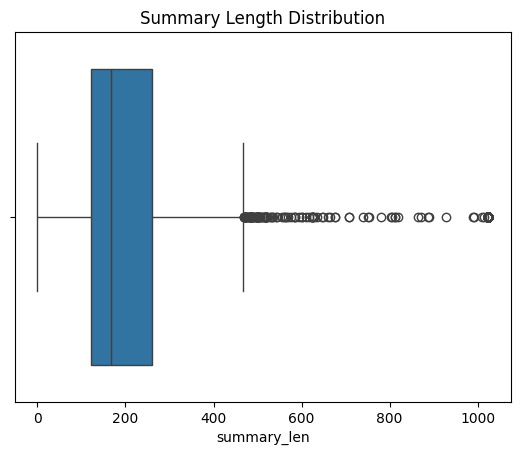

In [115]:
df['summary_len'] = df['summary'].str.len()

# Describe distribution
print(df['summary_len'].describe(percentiles=[0.01, 0.05, 0.95, 0.99]))

# Possible outliers
short_summaries = df[df['summary_len'] < df['summary_len'].quantile(0.01)]
long_summaries = df[df['summary_len'] > df['summary_len'].quantile(0.99)]

# Visual boxplot
sns.boxplot(x=df['summary_len'])
plt.title("Summary Length Distribution")
plt.show()

In [110]:
df['text'] = df['title'] + ". " + df['summary']
df['text_len'] = df['text'].str.len()

In [111]:
df['text_len'].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99])

count    55464.000000
mean       254.285753
std         95.625234
min         12.000000
1%          64.000000
25%        194.000000
50%        248.000000
75%        319.000000
95%        372.000000
99%        453.000000
max       1973.000000
Name: text_len, dtype: float64

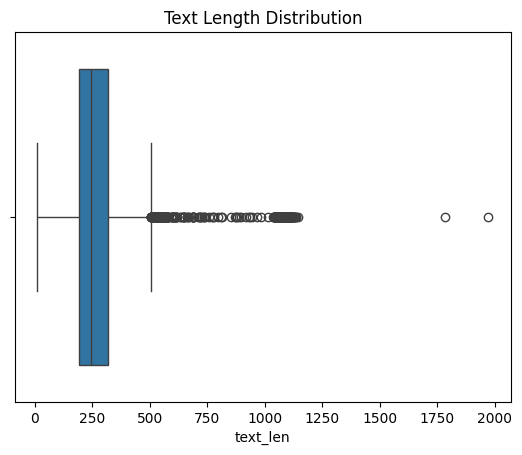

In [84]:
sns.boxplot(x=df['text_len'])
plt.title("Text Length Distribution")
plt.show()

In [ ]:
df[df['summary_len'] == 300].sample(5)

# Details

title_len                             summary_len         \
                mean median        std min   max        mean median   
source                                                                
worldnews  68.755316   68.0  25.711607   4   255  242.865316  167.0   
fcsapi     77.304167   78.0  16.557164  13   161  189.090717  188.0   
newsapi    73.297165   70.0  26.780089   0  1711  170.489435  160.0   

                                 
                  std min   max  
source                           
worldnews  232.401253   0  1024  
fcsapi      69.286047   0   990  
newsapi     75.711619   0   260

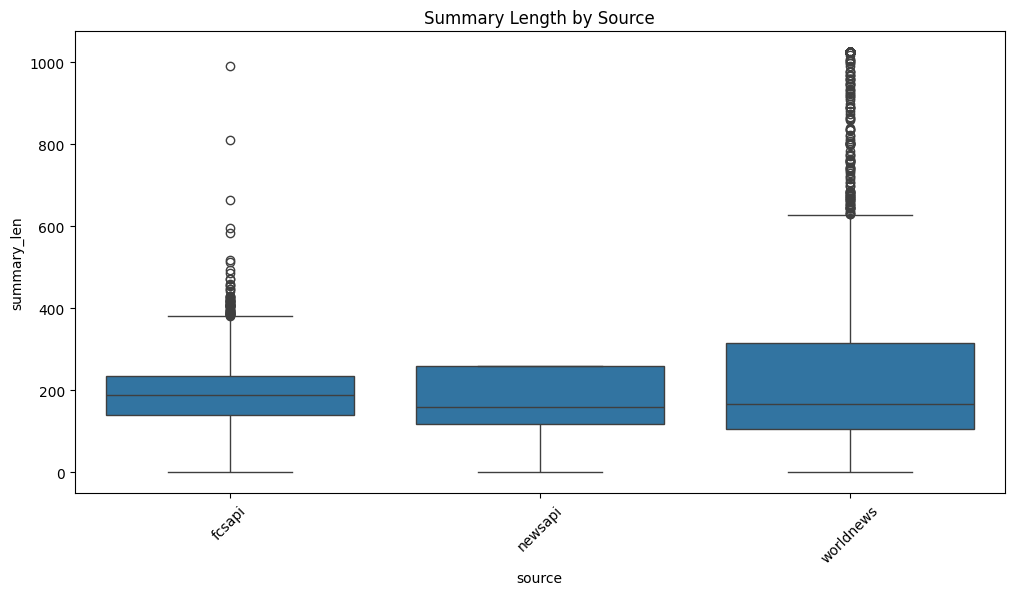

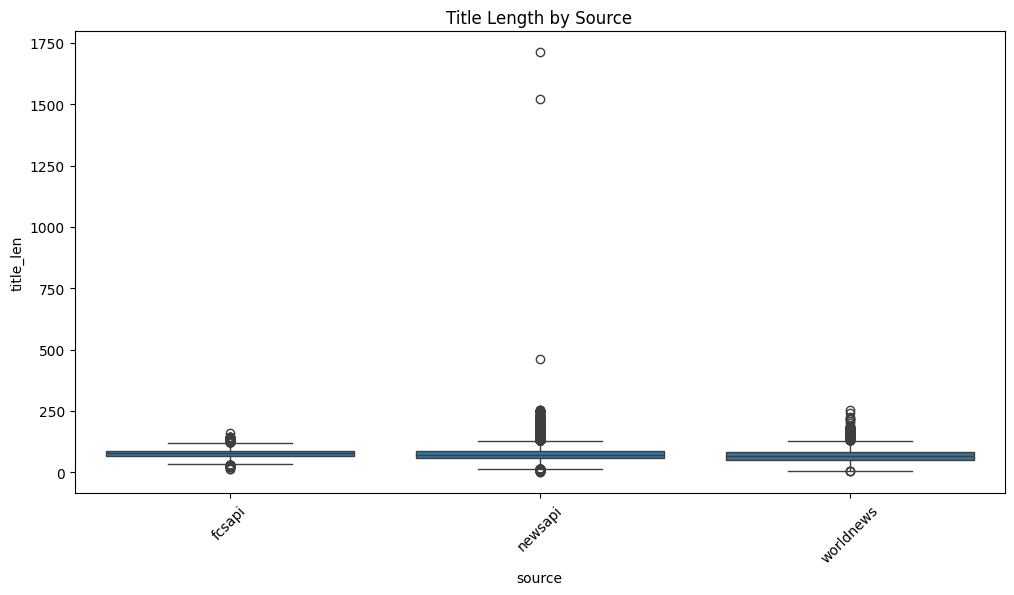

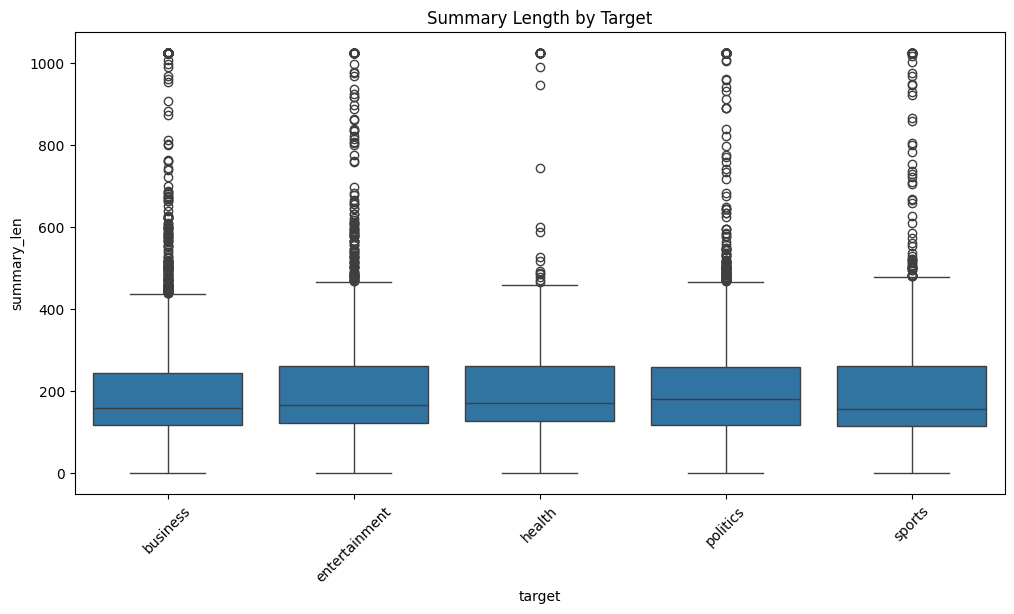

In [45]:
# Title and summary length by source
length_stats_by_source = df.groupby('source')[['title_len', 'summary_len']].agg(['mean', 'median', 'std', 'min', 'max']).sort_values(('summary_len', 'mean'), ascending=False)
display(length_stats_by_source.head(10))

# Boxplot: summary length by source
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='source', y='summary_len')
plt.xticks(rotation=45)
plt.title("Summary Length by Source")
plt.show()

# Boxplot: title length by source
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='source', y='title_len')
plt.xticks(rotation=45)
plt.title("Title Length by Source")
plt.show()

# (Optional) Do the same for 'target' (category/label)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='target', y='summary_len')
plt.xticks(rotation=45)
plt.title("Summary Length by Target")
plt.show()

In [50]:
for label in df['target'].unique():
    texts = df[df['target'] == label]['summary'].fillna('')
    vec = CountVectorizer(stop_words='english', max_features=10)
    X = vec.fit_transform(texts)
    print(f"Top words for label '{label}':")
    print(vec.get_feature_names_out(), "\n")

Top words for label 'business':
['2025' 'canada' 'company' 'economy' 'market' 'new' 'president' 'said'
 'trump' 'year'] 

Top words for label 'entertainment':
['2025' 'film' 'july' 'movie' 'music' 'new' 'star' 'time' 'tv' 'year'] 

Top words for label 'health':
['19' 'covid' 'disease' 'health' 'new' 'people' 'report' 'study' 'u2019s'
 'year'] 

Top words for label 'politics':
['canada' 'donald' 'federal' 'government' 'minister' 'new' 'president'
 'says' 'trump' 'u2019s'] 

Top words for label 'sports':
['2025' 'club' 'cup' 'football' 'nba' 'new' 'sports' 'wimbledon' 'world'
 'year'] 



In [52]:
dupes = df[df.duplicated(subset='title')]
print(f"Duplicate titles: {len(dupes)}")
dupes[['title', 'target']].head()

Duplicate titles: 0


,title,target


In [54]:
df['summary_len'].value_counts().sort_index().tail(10)  # show end of distribution

summary_len
864       1
872       1
887       1
889       1
928       1
990       1
992       1
1009      1
1015      1
1024    171
Name: count, dtype: int64

In [ ]:
print("Summaries with exactly 300 chars:", (df['summary_len'] == 300).sum())

Summaries with exactly 300 chars: 15


In [58]:
keywords = ['sports', 'economy', 'politic']
for word in keywords:
    mask = df['summary'].str.contains(word, case=False, na=False)
    print(f"\nArticles containing '{word}':")
    print(df[mask]['target'].value_counts(normalize=True))


Articles containing 'sports':
target
sports           0.693510
entertainment    0.153846
business         0.060096
politics         0.048077
health           0.044471
Name: proportion, dtype: float64

Articles containing 'economy':
target
business         0.858730
politics         0.115873
entertainment    0.015873
health           0.007937
sports           0.001587
Name: proportion, dtype: float64

Articles containing 'politic':
target
politics         0.634124
business         0.204380
entertainment    0.080292
health           0.068431
sports           0.012774
Name: proportion, dtype: float64


## Words

In [ ]:
def plot_top_ngrams(texts, ngram_range=(2,2), top_n=15, title="Top N-grams"):
    vec = CountVectorizer(stop_words='english', ngram_range = ngram_range, max_features = 10000)
    X = vec.fit_transform(texts)
    ngram_freq = dict(zip(vec.get_feature_names_out(), X.toarray().sum(axis=0)))
    top_ngrams = pd.Series(ngram_freq).sort_values(ascending=False).head(top_n)
    top_ngrams.plot(kind='barh', figsize=(10, 6), title=title)
    plt.xlabel("Frequency")
    plt.gca().invert_yaxis()
    plt.show()

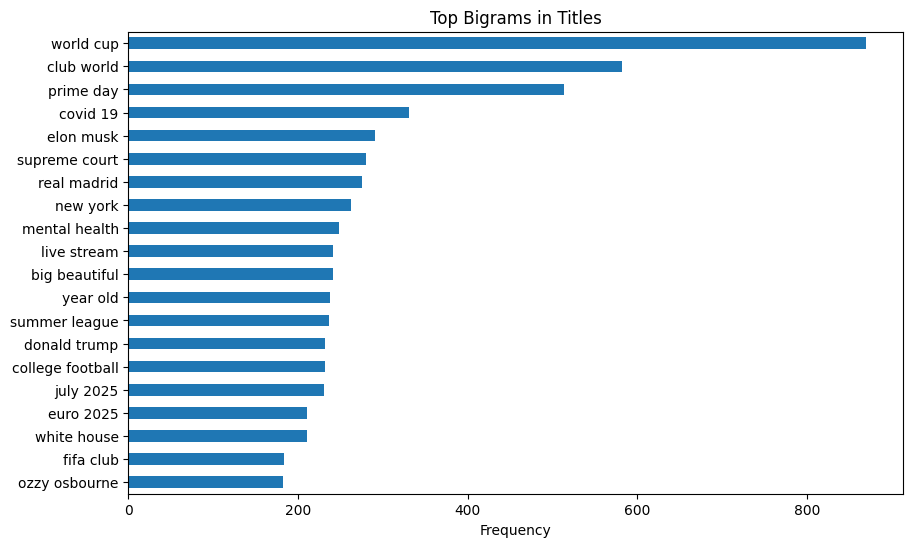

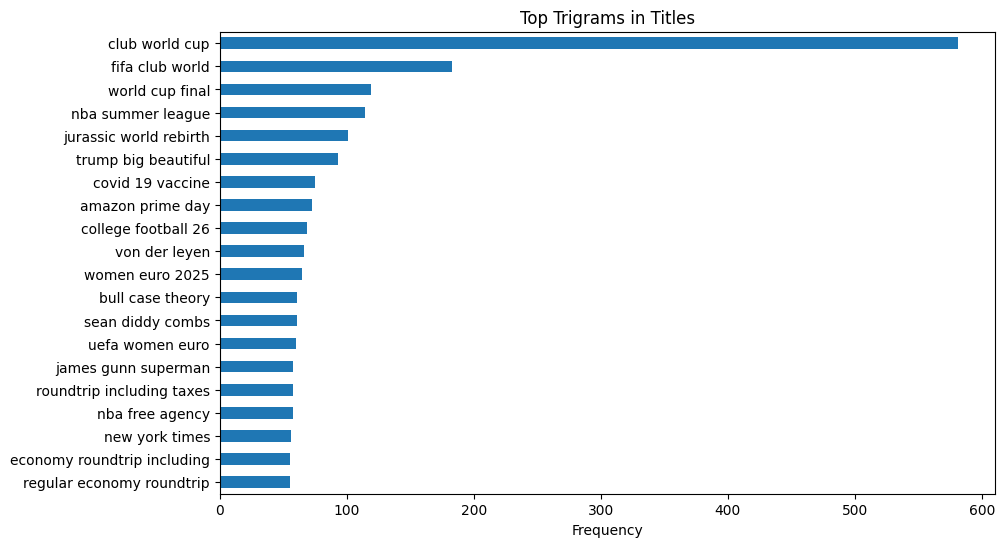

In [52]:
# Top bigrams in titles
plot_top_ngrams(df['title'].fillna(''), ngram_range=(2,2), top_n= 20, title="Top Bigrams in Titles")

# Top trigrams in titles
plot_top_ngrams(df['title'].fillna(''), ngram_range=(3,3), top_n = 20, title="Top Trigrams in Titles")

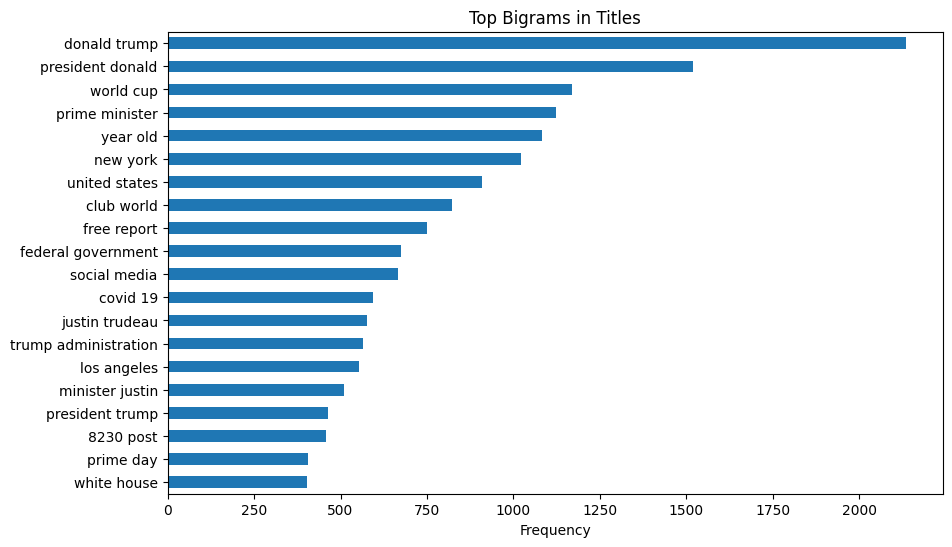

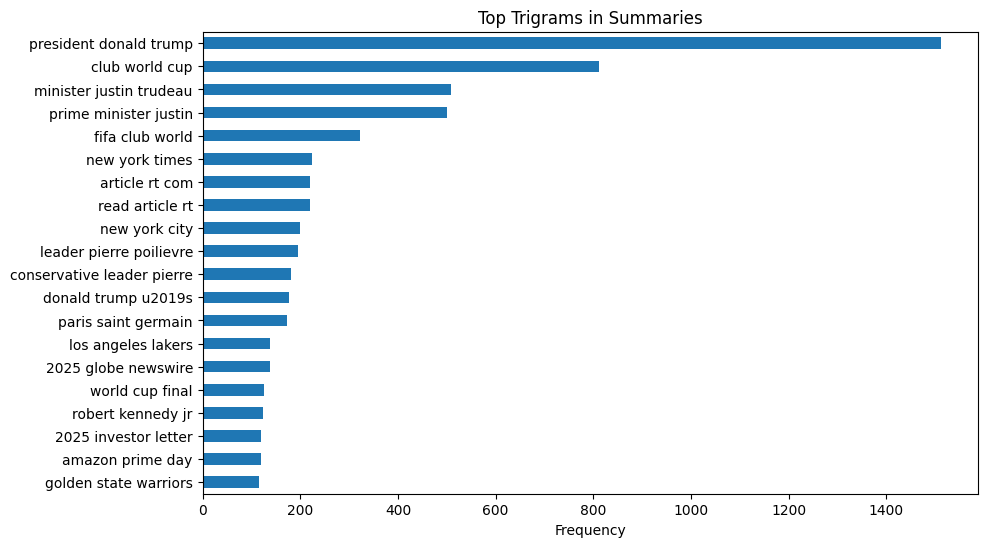

In [53]:
# Top bigrams in summaries
plot_top_ngrams(df['summary'].fillna(''), ngram_range=(2,2), top_n = 20, title = "Top Bigrams in Titles")

# Top trigrams in summaries
plot_top_ngrams(df['summary'].fillna(''), ngram_range=(3,3), top_n = 20, title = "Top Trigrams in Summaries")

In [32]:
df.duplicated(subset=['title', 'summary']).sum()

np.int64(0)

In [ ]:
df[df['summary'].str.contains("sports", case = False, na = False)]['target'].value_counts()

target
sports           577
entertainment    128
business          50
politics          40
health            37
Name: count, dtype: int64

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(df['summary'].fillna(''))

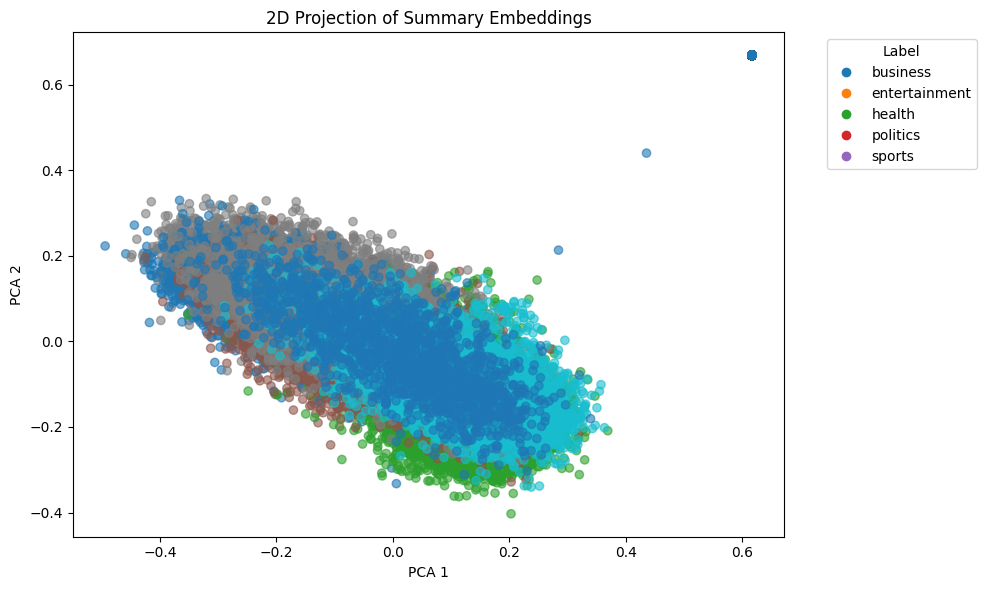

In [44]:
# Reduce to 2D
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

# Prepare label colors
labels = df['target']
label_ids, label_names = pd.factorize(labels)

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=label_ids, cmap='tab10', alpha=0.6)

# Add legend
handles = []
for i, label_name in enumerate(label_names):
    handles.append(plt.Line2D([], [], marker='o', linestyle='', color=plt.cm.tab10(i / 10), label=label_name))

plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', title="Label")
plt.title("2D Projection of Summary Embeddings")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.tight_layout()
plt.show()

## Topic Extraction

In [72]:
for label in df['target'].unique():
    texts = df[df['target'] == label]['summary'].fillna('')
    tfidf = TfidfVectorizer(stop_words='english', max_features=10)
    X = tfidf.fit_transform(texts)
    print(f"Top TF-IDF words for '{label}':", tfidf.get_feature_names_out())

Top TF-IDF words for 'business': ['2025' 'company' 'economy' 'market' 'new' 'president' 'said' 'stock'
 'trump' 'year']
Top TF-IDF words for 'entertainment': ['2025' 'film' 'july' 'movie' 'music' 'new' 'star' 'time' 'tv' 'year']
Top TF-IDF words for 'health': ['according' 'disease' 'health' 'healthcare' 'new' 'people' 'report'
 'said' 'study' 'year']
Top TF-IDF words for 'politics': ['canada' 'donald' 'federal' 'government' 'minister' 'new' 'president'
 'said' 'says' 'trump']
Top TF-IDF words for 'sports': ['2025' 'club' 'cup' 'football' 'league' 'new' 'season' 'sports' 'world'
 'year']


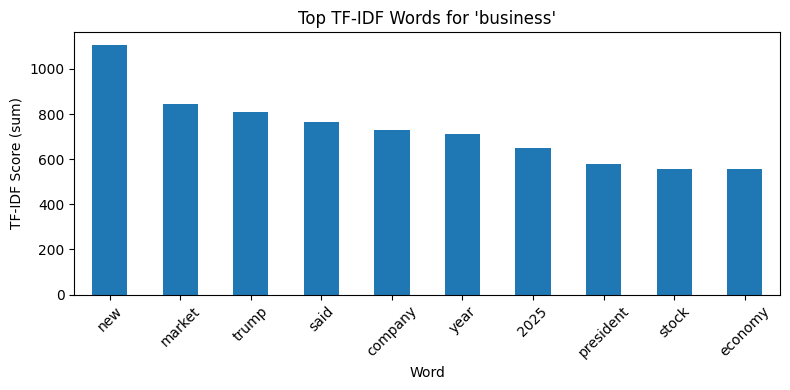

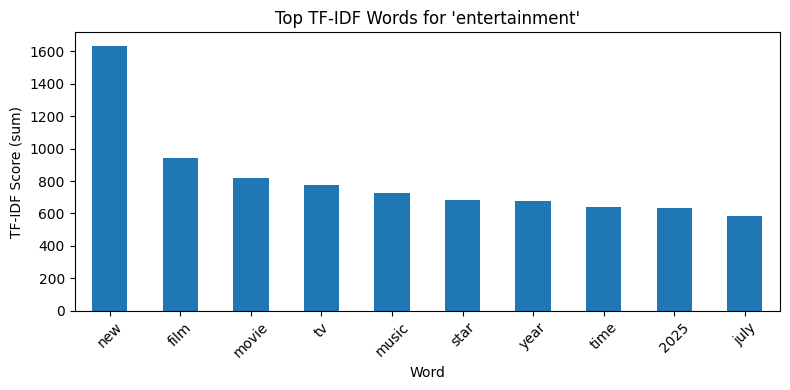

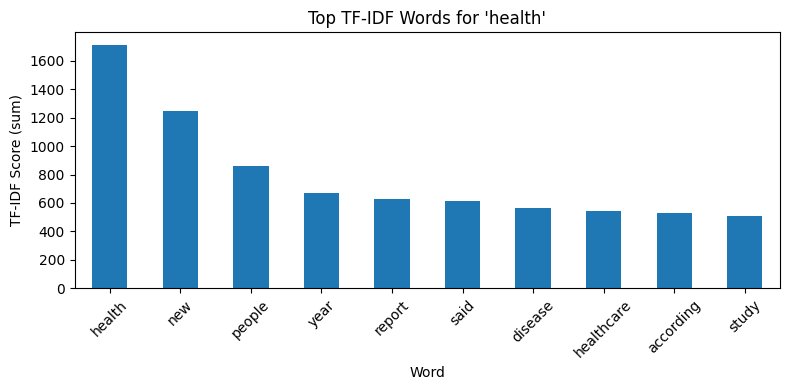

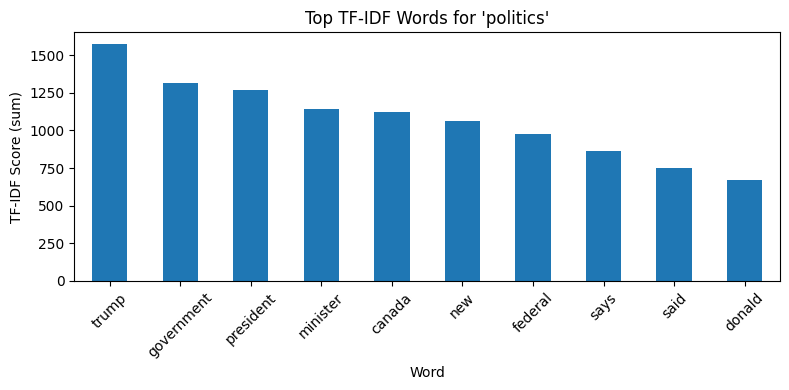

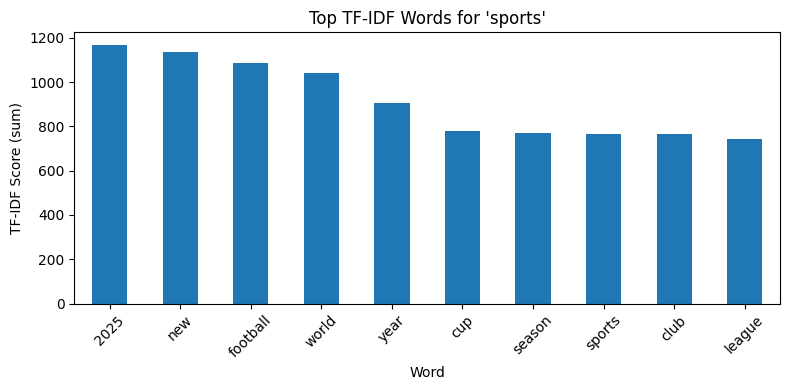

In [75]:
for label in df['target'].unique():
    texts = df[df['target'] == label]['summary'].fillna('')
    tfidf = TfidfVectorizer(stop_words='english', max_features=10)
    X = tfidf.fit_transform(texts)
    scores = X.sum(axis=0).A1
    words = tfidf.get_feature_names_out()
    top_words = pd.Series(scores, index=words).sort_values(ascending=False)
    
    plt.figure(figsize=(8, 4))
    top_words.plot(kind = 'bar')
    plt.xticks(rotation = 45)
    plt.title(f"Top TF-IDF Words for '{label}'")
    plt.ylabel("TF-IDF Score (sum)")
    plt.xlabel("Word")
    plt.tight_layout()
    plt.show()